# 01 · Multimodal Comedy classifier: small demo

Prototype of the whole idea on a **subset** of Tiny MM-IMDb, so it runs in about a minute on a laptop.

**Question:** given a movie's **poster** and **plot outline**, should it carry a *Comedy* tag?

**Approach:** two frozen pretrained transformers turn each input into a 768-d vector; a small MLP learns from the concatenated 1,536-d vector.

```
poster ─ ViT (google/vit-base-patch16-224-in21k) ─ [CLS] 768 ─┐
                                                              ├─ concat 1536 ─ MLP ─ Comedy logit
plot ─── DistilBERT (distilbert-base-uncased) ── mean 768 ────┘
```

Once this worked, the code moved to `src/` (full dataset, 3 seeds, baselines). See `reports/results.md` for the full-data numbers.

In [1]:
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score
from torch import nn
from transformers import AutoImageProcessor, AutoModel, AutoTokenizer, logging

logging.set_verbosity_error()
Image.MAX_IMAGE_PIXELS = 200_000_000  # a few dataset posters are ~100 MP
SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device

/Users/alvinngo122/Projects/movie_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'mps'

## 1. Data and labels

Each row has a poster, a plot, a genre list, and a supplied train/dev/test split. The **label** is whether `Comedy` appears in the genre list. Genres build `y` only; they never touch the inputs.

In [2]:
root = Path(kagglehub.dataset_download("gabrieltardochi/tiny-mm-imdb")) / "tinymmimdb"
df = pd.read_csv(root / "data.csv")
df["genres"] = df["genre"].str.split(" - ")
df["label"] = df["genres"].apply(lambda g: int("Comedy" in g))
df["image_file"] = df["image_path"].apply(lambda p: str(root / "images" / p))

print(df.shape)
df.groupby("split")["label"].agg(n="size", comedy="sum", rate="mean")

(4285, 9)


,n,comedy,rate
split,,,
dev,1071,378,0.352941
test,1072,344,0.320896
train,2142,734,0.342670


In [3]:
# Output cleared before committing: posters are dataset assets (see README > Scope).
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
for ax, (_, row) in zip(axes, df.sample(4, random_state=3).iterrows()):
    ax.imshow(Image.open(row.image_file)); ax.axis("off")
    ax.set_title(f"{row.title[:28]}\n{', '.join(row.genres)}\ncomedy={row.label}", fontsize=9)
plt.tight_layout()

### Demo subset

Stratified sample from each **supplied** split (no re-splitting), to keep the demo quick.

In [4]:
N = {"train": 600, "dev": 300, "test": 300}
sub = pd.concat([
    df[df.split == s].groupby("label").sample(frac=n / (df.split == s).sum(), random_state=SEED)
    for s, n in N.items()
]).reset_index(drop=True)
sub.groupby("split")["label"].agg(n="size", comedy="sum")

,n,comedy
split,,
dev,300,106
test,300,96
train,600,206


## 2. Frozen transformer encoders

* **Text:** DistilBERT returns one vector per token. Mean-pool them, **masking out padding** so short plots aren't diluted.
* **Image:** ViT splits the 224×224 poster into 16×16 patches (196 tokens + 1 `[CLS]`). Use the `[CLS]` output as the poster summary.

Encoders are frozen (`torch.no_grad`, `eval()`), so each movie is encoded once and the vectors are reused for every head experiment.

In [5]:
TEXT_MODEL, IMAGE_MODEL = "distilbert/distilbert-base-uncased", "google/vit-base-patch16-224-in21k"
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL)
text_encoder = AutoModel.from_pretrained(TEXT_MODEL).eval().to(device)
processor = AutoImageProcessor.from_pretrained(IMAGE_MODEL)
image_encoder = AutoModel.from_pretrained(IMAGE_MODEL, add_pooling_layer=False).eval().to(device)

def mean_pool(hidden, mask):
    mask = mask.unsqueeze(-1).to(hidden.dtype)
    return (hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

def load_poster(path):
    im = Image.open(path); im.draft("RGB", (448, 448))  # fast JPEG decode for huge posters
    return im.convert("RGB")

@torch.no_grad()
def embed_text(texts, bs=64):
    out = []
    for i in range(0, len(texts), bs):
        t = tokenizer(texts[i:i+bs], padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        out.append(mean_pool(text_encoder(**t).last_hidden_state, t["attention_mask"]).cpu())
    return torch.cat(out)

@torch.no_grad()
def embed_images(paths, bs=32):
    out = []
    for i in range(0, len(paths), bs):
        px = processor(images=[load_poster(p) for p in paths[i:i+bs]], return_tensors="pt")["pixel_values"].to(device)
        out.append(image_encoder(pixel_values=px).last_hidden_state[:, 0].cpu())  # [CLS]
    return torch.cat(out)

# Shapes for one example
t = tokenizer([sub["plot outline"].iloc[0]], return_tensors="pt").to(device)
px = processor(images=[load_poster(sub.image_file.iloc[0])], return_tensors="pt")["pixel_values"].to(device)
with torch.no_grad():
    print("text tokens  ", tuple(text_encoder(**t).last_hidden_state.shape), "-> pooled (1, 768)")
    print("image patches", tuple(image_encoder(pixel_values=px).last_hidden_state.shape), "-> [CLS] (1, 768)")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8695.02it/s]


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 6944.97it/s]

text tokens   (1, 34, 768) -> pooled (1, 768)


image patches (1, 197, 768) -> [CLS] (1, 768)


In [6]:
%%time
text_emb = embed_text(sub["plot outline"].tolist())
image_emb = embed_images(sub["image_file"].tolist())
text_emb.shape, image_emb.shape

CPU times: user 6.01 s, sys: 1.43 s, total: 7.43 s
Wall time: 31.1 s


(torch.Size([1200, 768]), torch.Size([1200, 768]))

## 3. Fusion head

Per-modality `LayerNorm` (the two encoders produce vectors on different scales), concatenate, then a 2-layer MLP producing **one logit**. Single-modality baselines are the same head given one input.

In [7]:
class GenreHead(nn.Module):
    def __init__(self, modalities, dim=768, hidden=256, dropout=0.2):
        super().__init__()
        self.modalities = modalities
        self.norms = nn.ModuleDict({m: nn.LayerNorm(dim) for m in modalities})
        self.mlp = nn.Sequential(nn.Linear(dim * len(modalities), hidden), nn.ReLU(),
                                 nn.Dropout(dropout), nn.Linear(hidden, 1))

    def forward(self, feats):
        return self.mlp(torch.cat([self.norms[m](feats[m]) for m in self.modalities], -1)).squeeze(-1)

def split_data(name):
    idx = torch.from_numpy(np.flatnonzero(sub.split.to_numpy() == name))
    return {"text": text_emb[idx], "image": image_emb[idx]}, torch.tensor(sub.label.to_numpy()[idx], dtype=torch.float32)

data = {s: split_data(s) for s in N}

## 4. Train

`BCEWithLogitsLoss` with `pos_weight` for class imbalance, AdamW, and keep the epoch with the best **dev** average precision (early stopping). The decision threshold is also chosen on dev; test is only scored at the end.

In [8]:
def train(modalities, epochs=40, lr=1e-3, bs=64):
    torch.manual_seed(SEED)
    (xtr, ytr), (xdv, ydv) = data["train"], data["dev"]
    model = GenreHead(modalities)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=(ytr == 0).sum() / (ytr == 1).sum())
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    best_ap, best_state, curve = -1, None, []
    for epoch in range(epochs):
        model.train()
        for b in torch.randperm(len(ytr)).split(bs):
            loss = loss_fn(model({m: xtr[m][b] for m in modalities}), ytr[b])
            opt.zero_grad(); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            ap = average_precision_score(ydv, torch.sigmoid(model(xdv)))
        curve.append(ap)
        if ap > best_ap:
            best_ap, best_state = ap, {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return model, curve

def scores(model, split):
    with torch.no_grad():
        return torch.sigmoid(model(data[split][0])).numpy()

def best_f1_threshold(y, s):
    grid = np.unique(s)
    return grid[np.argmax([f1_score(y, s >= t) for t in grid])]

In [9]:
results, curves = [], {}
for name, mods in {"text (plot)": ("text",), "image (poster)": ("image",), "fusion": ("text", "image")}.items():
    model, curves[name] = train(mods)
    thr = best_f1_threshold(data["dev"][1].numpy(), scores(model, "dev"))
    y, s = data["test"][1].numpy(), scores(model, "test")
    results.append({"model": name, "test AP": average_precision_score(y, s),
                    "test ROC AUC": roc_auc_score(y, s), "test F1": f1_score(y, s >= thr), "dev threshold": thr})
pd.DataFrame(results).set_index("model").round(3)

,test AP,test ROC AUC,test F1,dev threshold
model,,,,
text (plot),0.611,0.756,0.579,0.578
image (poster),0.560,0.715,0.550,0.442
fusion,0.656,0.777,0.559,0.500


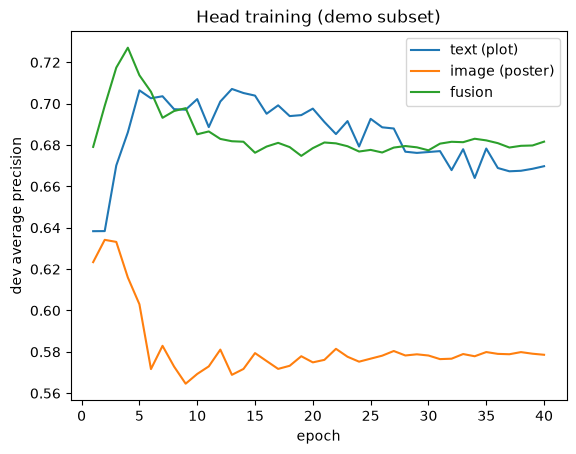

In [10]:
for name, c in curves.items():
    plt.plot(range(1, len(c) + 1), c, label=name)
plt.xlabel("epoch"); plt.ylabel("dev average precision"); plt.legend(); plt.title("Head training (demo subset)");

## 5. Takeaways and the move to scripts

* On this small subset, numbers are noisy (300 test movies, one seed). Treat them as a smoke test.
* The full pipeline lives in `src/` and extends this prototype with a second encoder family (SigLIP 2), a gated fusion unit, a token-level fusion transformer, LoRA fine-tuning, and multilabel genres:

| Step | Command |
| --- | --- |
| Validate data | `python -m src.data` |
| Cache encoder outputs (pooled + tokens) | `python -m src.embed --backbone vit_distilbert` / `--backbone siglip2` |
| Baselines (majority, TF-IDF, SigLIP 2 zero-shot) | `python -m src.baselines`, `python -m src.zeroshot` |
| Frozen-encoder heads, all backbones × heads × 3 seeds | `python -m src.train --task binary` |
| LoRA fine-tuning | `python -m src.finetune --backbone siglip2_distilbert --head concat` |
| Multilabel genres | `python -m src.train --task multilabel --experiments ...` |
| Results, figures, error analysis, latency | `python -m src.report`, `python -m src.analysis`, `python -m src.benchmark` |

Full-data results: `reports/results.md`.